In [16]:
import pandas as pd
import numpy as np

In [2]:
from google.colab import drive
drive.mount('/content/drive')
path = '/content/drive/MyDrive/311_Service_Requests.csv'

Mounted at /content/drive


##Data Prep

In [ ]:
# @title
"""
# load data
use_cols = [
    "Created Date",
    "Closed Date",
    "Agency",
    "Problem (formerly Complaint Type)",
    "Location Type",
    "Incident Zip",
    "Police Precinct",
    "Borough"
]

df = pd.read_csv(path, usecols=use_cols)
df = df.dropna()

# filter df to top 10
top10 = df['Problem (formerly Complaint Type)'].value_counts().head(10)
df = df[df['Problem (formerly Complaint Type)'].isin(top10.index)]

print(df.info())
df.head()

save_path = "/content/drive/MyDrive/cleaned_311_data.csv"
df.to_csv(save_path, index=False)
"""

In [63]:
save_path = "/content/drive/MyDrive/cleaned_311_data.csv"

df = pd.read_csv(save_path)
df = df.sample(n=50000, random_state=42)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, 3427093 to 3517283
Data columns (total 8 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Created Date                       50000 non-null  object 
 1   Closed Date                        50000 non-null  object 
 2   Agency                             50000 non-null  object 
 3   Problem (formerly Complaint Type)  50000 non-null  object 
 4   Location Type                      50000 non-null  object 
 5   Incident Zip                       50000 non-null  float64
 6   Police Precinct                    50000 non-null  object 
 7   Borough                            50000 non-null  object 
dtypes: float64(1), object(7)
memory usage: 3.4+ MB


In [99]:
# rename columns
df = df.rename(columns={
    'Problem (formerly Complaint Type)': 'complaint_type',
    'Created Date': 'created_date',
    'Closed Date': 'closed_date',
    'Location Type': 'location_type',
    'Incident Zip': 'incident_zip',
    'Police Precinct': 'police_precinct',
    'Agency': 'agency',
    'Borough': 'borough'
})

# turn date into datetime
df['created_date'] = pd.to_datetime(df['created_date'])
df['closed_date'] = pd.to_datetime(df['closed_date'])

# calculate resolution hours
df['resolution_hours'] = (df['closed_date'] - df['created_date']).dt.total_seconds() / 3600
print(f"Mean Resolution Time: {df['resolution_hours'].mean()}")

# break created data up into hour, day of week, and month
df['hour'] = df['created_date'].dt.hour
df['day_of_week'] = df['created_date'].dt.dayofweek
df['month'] = df['created_date'].dt.month

df.info()

Mean Resolution Time: 65.79768636666667
<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, 3427093 to 3517283
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   created_date      50000 non-null  datetime64[ns]
 1   closed_date       50000 non-null  datetime64[ns]
 2   agency            50000 non-null  object        
 3   complaint_type    50000 non-null  object        
 4   location_type     50000 non-null  object        
 5   incident_zip      50000 non-null  float64       
 6   police_precinct   50000 non-null  object        
 7   borough           50000 non-null  object        
 8   resolution_hours  50000 non-null  float64       
 9   hour              50000 non-null  int32         
 10  day_of_week       50000 non-null  int32         
 11  month             50000 non-null  int32         
 12  hour_sin          50000 non-null  float64       
 13  hour_cos          50000 non-null 

In [100]:
# sine/cosine cyclic encoding for temporal features
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

In [101]:
X = df.drop(columns=['created_date', 'closed_date', 'resolution_hours', 'hour', 'day_of_week', 'month'])
y = np.log1p(df['resolution_hours'])

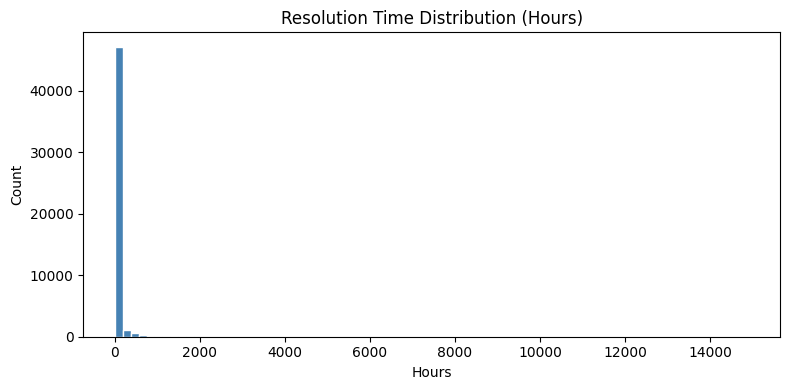

In [131]:
# Resolution Time Distribution
plt.figure(figsize=(8, 4))
plt.hist(df['resolution_hours'], bins=80, color='steelblue', edgecolor='white')
plt.title('Resolution Time Distribution (Hours)')
plt.xlabel('Hours')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

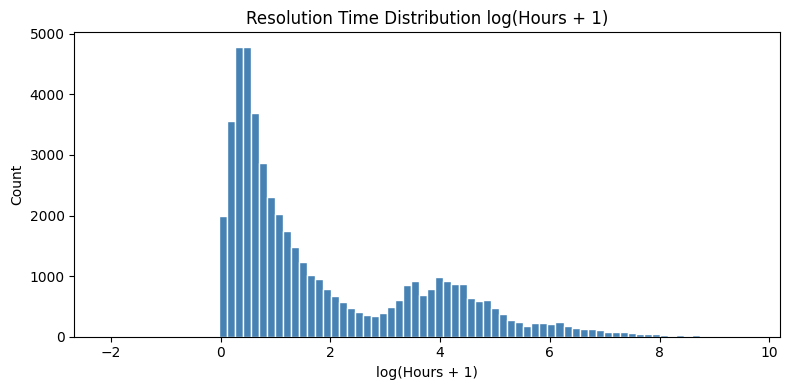

In [127]:
# Resolution Time Distribution
plt.figure(figsize=(8, 4))
plt.hist(y, bins=80, color='steelblue', edgecolor='white')
plt.title('Resolution Time Distribution log(Hours + 1)')
plt.xlabel('log(Hours + 1)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [102]:
from sklearn.model_selection import train_test_split

# split into train, test, val
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42)

print(X_train.shape, X_val.shape, X_test.shape)

(35000, 12) (7500, 12) (7500, 12)


##Model Training

In [103]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# encode categorial columns (all)
cat_cols = [
    "agency",
    "complaint_type",
    "location_type",
    "incident_zip",
    "police_precinct",
    "borough"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

In [117]:
# define model
model = MLPRegressor(
    hidden_layer_sizes=(256, 128, 64),
    activation="relu",
    solver="sgd",
    max_iter=500,
    random_state=42,
    early_stopping=True,
    learning_rate_init=0.001,
    learning_rate="adaptive",
)

In [118]:
# pipeline
pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", model)
])

In [119]:
# fit data
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['agency', 'complaint_type',
                                                   'location_type',
                                                   'incident_zip',
                                                   'police_precinct',
                                                   'borough'])])),
                ('model',
                 MLPRegressor(early_stopping=True,
                              hidden_layer_sizes=(256, 128, 64),
                              learning_rate='adaptive', max_iter=500,
                              random_state=42, solver='sgd'))])

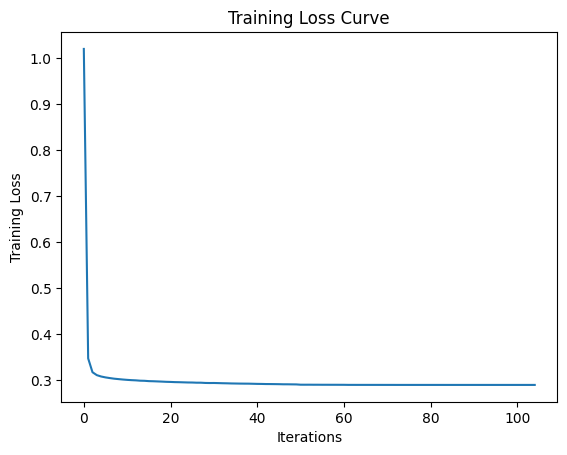

In [120]:
import matplotlib.pyplot as plt

loss_curve = pipeline.named_steps["model"].loss_curve_

plt.plot(loss_curve)
plt.xlabel("Iterations")
plt.ylabel("Training Loss")
plt.title("Training Loss Curve")
plt.show()

In [121]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# valdiation dataset
y_pred_log = pipeline.predict(X_val)
y_pred = np.expm1(y_pred_log)
y_val_actual = np.expm1(y_val)

mae = mean_absolute_error(y_val_actual, y_pred)
mse = mean_squared_error(y_val_actual, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_val_actual, y_pred)

print(f"MAE:  {mae:.2f} hours")
print(f"RMSE: {rmse:.2f} hours")
print(f"MSE:  {mse:.2f}")
print(f"R^2:   {r2:.4f}")

MAE:  52.28 hours
RMSE: 324.67 hours
MSE:  105411.70
R^2:   0.1496


##Model Eval

In [122]:
# evaluate with test dataset
y_pred_log = pipeline.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_test_actual = np.expm1(y_test)

mae = mean_absolute_error(y_test_actual, y_pred)
mse = mean_squared_error(y_test_actual, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_actual, y_pred)

print(f"MAE:  {mae:.2f} hours")
print(f"RMSE: {rmse:.2f} hours")
print(f"MSE:  {mse:.2f}")
print(f"R^2:   {r2:.4f}")

MAE:  52.28 hours
RMSE: 367.08 hours
MSE:  134745.35
R^2:   0.1267


In [123]:
import joblib

joblib.dump(model, 'model.joblib')
loaded_model = joblib.load('model.joblib')